In [1]:
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tqdm
import cmocean 

## Sort OAG processed data

In [2]:
# Load the csv as a pandas dataframe
df = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/OAG_processing/OAG_processed.csv')
df

,Aircraft.Type,Number_of_Operations,Annual_Distance,Annual_Fuelburn
0,100,47137.0,1.755986e+07,1.246481e+08
1,142,252.0,3.458908e+04,2.497959e+05
2,146,9908.0,2.841992e+06,2.149576e+07
3,220,165.0,0.000000e+00,0.000000e+00
4,221,74762.0,5.473592e+07,3.520434e+08
...,...,...,...,...
170,SWM,26169.0,3.579164e+06,5.962485e+06
171,T12,21489.0,0.000000e+00,0.000000e+00
172,T20,2.0,4.120243e+03,3.555414e+04
173,YK2,302.0,1.367390e+05,1.351686e+06


In [3]:
# Sort the dataset in descending order of the annual distance
df_distance = df.sort_values(by='Annual_Distance', ascending=False)

# Sort the dataset in decending order of the annual fuelburn
df_fuelburn = df.sort_values(by='Annual_Fuelburn', ascending=False)

In [4]:
df_fuelburn[0:15]

,Aircraft.Type,Number_of_Operations,Annual_Distance,Annual_Fuelburn
14,320,5831543.0,3.683754e+09,2.547156e+10
73,77W,315318.0,9.307615e+08,1.678611e+10
42,738,3199288.0,2.232648e+09,1.644452e+10
48,73H,2543511.0,1.888043e+09,1.377133e+10
15,321,2080007.0,1.528355e+09,1.315542e+10
77,789,263346.0,8.109044e+08,9.470105e+09
32,359,191604.0,5.204574e+08,7.189357e+09
23,333,249808.0,4.739592e+08,6.560356e+09
11,319,1421489.0,8.145631e+08,5.637238e+09
76,788,194449.0,4.683226e+08,5.299036e+09


In [5]:
# Print the top 5 aircraft in terms of annual distance
df_distance[0:15]

,Aircraft.Type,Number_of_Operations,Annual_Distance,Annual_Fuelburn
14,320,5831543.0,3.683754e+09,2.547156e+10
42,738,3199288.0,2.232648e+09,1.644452e+10
48,73H,2543511.0,1.888043e+09,1.377133e+10
15,321,2080007.0,1.528355e+09,1.315542e+10
73,77W,315318.0,9.307615e+08,1.678611e+10
11,319,1421489.0,8.145631e+08,5.637238e+09
77,789,263346.0,8.109044e+08,9.470105e+09
18,32N,842884.0,6.736562e+08,4.034433e+09
80,7M8,560611.0,5.630983e+08,3.301271e+09
54,73W,912944.0,5.412637e+08,3.865679e+09


## Plot flight paths from AEIC data

In [6]:
# Import OAG data from NetCDF file
df_OAG_plot = xr.open_dataset('/home/chinahg/GCresearch/contrailuncertainty/OAG_processing/AEIC_2022_30Nto60N/GEOS-Chem_Emission/AEIC_2022.geos5.1x1.46L.nc')

# Check the data structure and variables
df_OAG_plot.sel(time='2022-01-01T00:00:00',lev='10')

/home/chinahg/.conda/envs/contrails/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.30.0
  warnings.warn(


<xarray.Dataset>
Dimensions:   (lat: 180, lon: 360)
Coordinates:
    time      datetime64[ns] 2022-01-01
    lev       float64 10.0
  * lat       (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    HC        (lat, lon) float32 ...
    NO2       (lat, lon) float32 ...
    CO        (lat, lon) float32 ...
    NO        (lat, lon) float32 ...
    FUELBURN  (lat, lon) float32 ...
    BC        (lat, lon) float32 ...
    HONO      (lat, lon) float32 ...
    OC        (lat, lon) float32 ...
    DISTANCE  (lat, lon) float32 ...
Attributes:
    Title:           Aviation Emissions Inventory Code (AEIC) dataset for 2022
    Contact:         Sebastian D. Eastham (seastham@mit.edu)
    GeneratedBy:     Thibaud M. Fritz (fritzt@mit.edu)
    GenerationDate:  Mon Jun 17 14:41:55 24 EST
    Start_Date:      2022-01-01
    End_Date:        2023-01-01
    Start_Time:      00:00:00.0
    End_Time:        23:59:59.9

In [7]:
# Define latitude, longitude, time, and distance
lat = df_OAG_plot['lat']
lon = df_OAG_plot['lon']
fuelburn = df_OAG_plot['FUELBURN'][0,10,:,:] # at 11km atltitude
distance = df_OAG_plot['DISTANCE']
df_OAG_plot_pared = df_OAG_plot.sel(time='2022-01-01T00:00:00',lev='11')

In [8]:
# Make a pivot table for fuelburn
fuelburn_pivot = df_OAG_plot_pared.to_dataframe().pivot_table(index='lat', columns='lon', values='FUELBURN')
fuelburn_pivot

lon,-179.5,-178.5,-177.5,-176.5,-175.5,-174.5,-173.5,-172.5,-171.5,-170.5,...,170.5,171.5,172.5,173.5,174.5,175.5,176.5,177.5,178.5,179.5
lat,,,,,,,,,,,,,,,,,,,,,
-89.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-88.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-87.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-86.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-85.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
87.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0.5, 0, 'Fuel Burn in km/m2/s')

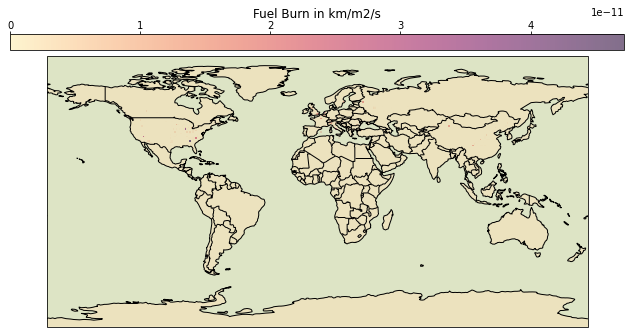

In [9]:
cmap = cmocean.cm.matter

fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})

ax._autoscaleXon = False
ax._autoscaleYon = False

ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

c = ax.pcolormesh(
    lon,
    lat,
    fuelburn_pivot,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    alpha=0.6
)

cbar = fig.colorbar(
    c, ax=ax, orientation="horizontal", location="top", pad=0.02, aspect=40
)

cbar.ax.tick_params(labelsize=10, pad=0)
cbar.ax.set_xlabel("Fuel Burn in km/m2/s", fontsize=12)

IndexError: too many indices

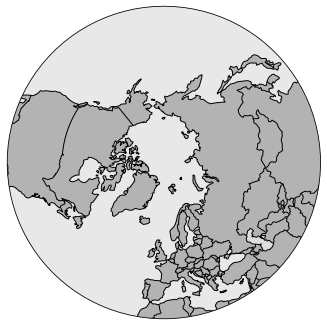

In [10]:
coastline_width = 1
coastline_color = "black"
coastline_alpha = 1

border_width = 1
border_color = "black"
border_alpha = 1
border_linestyle = "solid"

land_color = "grey"
land_alpha = 0.5

ocean_color = "lightgray"
ocean_alpha = 0.5
# Create the meshgrid

lon, lat = np.meshgrid(lon, lat)

# cmap = cm.get_cmap("coolwarm")
cmap = cmocean.cm.matter
cmap_name = "matter"

projection = ccrs.NorthPolarStereo(
    central_longitude=0
)  # ccrs.NearsidePerspective(central_longitude=0, central_latitude=90, satellite_height=5000000)

fig = plt.figure(figsize=(7, 5.75))
ax = plt.axes(projection=projection)
ax._autoscaleXon = False
ax._autoscaleYon = False


ax.set_extent([-180, 180, 30, 60], ccrs.PlateCarree())
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=coastline_width,
    edgecolor=coastline_color,
    alpha=coastline_alpha
)
ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor=land_color, alpha=land_alpha)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=border_width,
    edgecolor=border_color,
    alpha=border_alpha,
    linestyle=border_linestyle
)

# ax.gridlines(
#     color="C7",
#     lw=1,
#     ls=":",
#     draw_labels=True,
#     rotate_labels=False,
#     ylocs=[60, 70, 80],
# )

c = ax.pcolormesh(
    lon,
    lat,
    fuelburn[0,10,:,:],
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    alpha=1
)